To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth on your local device, follow [our guide](https://unsloth.ai/docs/get-started/install). This notebook is licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & how to save it

### News

Introducing **Unsloth Studio** - a new open source, no-code web UI to train and run LLMs. [Blog](https://unsloth.ai/docs/new/studio) • [Notebook](https://colab.research.google.com/github/unslothai/unsloth/blob/main/studio/Unsloth_Studio_Colab.ipynb)

<table><tr>
<td align="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Zq%252Fuploads%252FxV1PO5DbF3ksB51nE2Tw%252Fmore%2520cropped%2520ui%2520for%2520homepage.png%3Falt%3Dmedia%26token%3Df75942c9-3d8d-4b59-8ba2-1a4a38de1b86&width=376&dpr=3&quality=100&sign=a663c397&sv=2" width="200" height="120" alt="Unsloth Studio Training UI"></a><br><sub><b>Train models</b> — no code needed</sub></td>
<td align="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Zq%252Fuploads%252FRCnTAZ6Uh88DIlU3g0Ij%252Fmainpage%2520unsloth.png%3Falt%3Dmedia%26token%3D837c96b6-bd09-4e81-bc76-fa50421e9bfb&width=376&dpr=3&quality=100&sign=c1a39da1&sv=2" width="200" height="120" alt="Unsloth Studio Chat UI"></a><br><sub><b>Run GGUF models</b> on Mac, Windows & Linux</sub></td>
</tr></table>

Train MoEs - DeepSeek, GLM, Qwen and gpt-oss 12x faster with 35% less VRAM. [Blog](https://unsloth.ai/docs/new/faster-moe)

Ultra Long-Context Reinforcement Learning is here with 7x more context windows! [Blog](https://unsloth.ai/docs/new/grpo-long-context)

New in Reinforcement Learning: [FP8 RL](https://unsloth.ai/docs/new/fp8-reinforcement-learning) • [Vision RL](https://unsloth.ai/docs/new/vision-reinforcement-learning-vlm-rl) • [Standby](https://unsloth.ai/docs/basics/memory-efficient-rl) • [gpt-oss RL](https://unsloth.ai/docs/new/gpt-oss-reinforcement-learning)

Visit our docs for all our [model uploads](https://unsloth.ai/docs/get-started/unsloth-model-catalog) and [notebooks](https://unsloth.ai/docs/get-started/unsloth-notebooks).

### Installation

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install jiwer
!pip install einops addict easydict

### Unsloth

Let's prepare the OCR model to our local first

In [2]:
from huggingface_hub import snapshot_download
snapshot_download("unsloth/DeepSeek-OCR-2", local_dir = "deepseek_ocr2")

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

deepencoderv2.py: 0.00B [00:00, ?B/s]

configuration_deepseek_v2.py: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

conversation.py: 0.00B [00:00, ?B/s]

...

processor_config.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

'/content/deepseek_ocr2'

In [3]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch
from transformers import AutoModel
import os
os.environ["UNSLOTH_WARN_UNINITIALIZED"] = '0'
# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Qwen3-VL-8B-Instruct-bnb-4bit", # Qwen 3 vision support
    "unsloth/Qwen3-VL-8B-Thinking-bnb-4bit",
    "unsloth/Qwen3-VL-32B-Instruct-bnb-4bit",
    "unsloth/Qwen3-VL-32B-Thinking-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastVisionModel.from_pretrained(
    "./deepseek_ocr2",
    load_in_4bit = False, # Use 4bit to reduce memory use. False for 16bit LoRA.
    auto_model = AutoModel,
    trust_remote_code = True,
    unsloth_force_compile = True,
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


🦥 Unsloth Zoo will now patch everything to make training faster!


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR2. This is not supported for all configurations of models and can yield errors.


Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.6.9: Fast Deepseekocr2 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


In [4]:
!pip uninstall -y torchao

Found existing installation: torchao 0.17.0
Uninstalling torchao-0.17.0:
  Successfully uninstalled torchao-0.17.0


In [5]:
# Dataset gốc:
!gdown 1UUQhNvzgpZy7zXBFQp0Qox-BBjunZ0ml
# hoạc bản Converted COCO
# !gdown --id 1UUQhNvzgpZy7zXBFQp0Qox-BBjunZ0ml

Downloading...
From (original): https://drive.google.com/uc?id=1UUQhNvzgpZy7zXBFQp0Qox-BBjunZ0ml
From (redirected): https://drive.google.com/uc?id=1UUQhNvzgpZy7zXBFQp0Qox-BBjunZ0ml&confirm=t&uuid=1363c97d-a3fa-48c1-a2ff-f81c851c837e
To: /content/vietnamese_original.zip
100% 1.05G/1.05G [00:10<00:00, 100MB/s] 


In [6]:
# Kiểm tra file:
import os

print(os.listdir("."))

['.config', 'deepseek_ocr2', 'unsloth_compiled_cache', 'vietnamese_original.zip', 'sample_data']


In [7]:
# giải nén
import zipfile

with zipfile.ZipFile("vietnamese_original.zip", "r") as zip_ref:
    zip_ref.extractall("VinText")

In [10]:
!ls -lh

total 1000M
drwxr-xr-x 4 root root  4.0K Jun 27 03:17 deepseek_ocr2
drwxr-xr-x 1 root root  4.0K Jun  4 13:39 sample_data
drwxr-xr-x 4 root root  4.0K Jun 27 03:18 unsloth_compiled_cache
-rw-r--r-- 1 root root 1000M May 12  2021 vietnamese_original.zip
drwxr-xr-x 3 root root  4.0K Jun 27 03:21 VinText


In [11]:
!find VinText -maxdepth 3 | head -100

VinText
VinText/vietnamese
VinText/vietnamese/vn_dictionary.txt
VinText/vietnamese/general_dict.txt
VinText/vietnamese/labels
VinText/vietnamese/labels/gt_812.txt
VinText/vietnamese/labels/gt_207.txt
VinText/vietnamese/labels/gt_1142.txt
VinText/vietnamese/labels/gt_1002.txt
VinText/vietnamese/labels/gt_1889.txt
VinText/vietnamese/labels/gt_1709.txt
VinText/vietnamese/labels/gt_825.txt
VinText/vietnamese/labels/gt_643.txt
VinText/vietnamese/labels/gt_1992.txt
VinText/vietnamese/labels/gt_691.txt
VinText/vietnamese/labels/gt_120.txt
VinText/vietnamese/labels/gt_1821.txt
VinText/vietnamese/labels/gt_354.txt
VinText/vietnamese/labels/gt_968.txt
VinText/vietnamese/labels/gt_169.txt
VinText/vietnamese/labels/gt_1496.txt
VinText/vietnamese/labels/gt_1611.txt
VinText/vietnamese/labels/gt_670.txt
VinText/vietnamese/labels/gt_983.txt
VinText/vietnamese/labels/gt_900.txt
VinText/vietnamese/labels/gt_1823.txt
VinText/vietnamese/labels/gt_516.txt
VinText/vietnamese/labels/gt_832.txt
VinText/vietna

In [12]:
import os

for root, dirs, files in os.walk("VinText"):
  print(root)
  print("dirs =", dirs[:5])
  print("files =", files[:5])
  print("-"*50)

VinText
dirs = ['vietnamese']
files = []
--------------------------------------------------
VinText/vietnamese
dirs = ['labels', 'unseen_test_images', 'train_images', 'test_image']
files = ['vn_dictionary.txt', 'general_dict.txt']
--------------------------------------------------
VinText/vietnamese/labels
dirs = []
files = ['gt_812.txt', 'gt_207.txt', 'gt_1142.txt', 'gt_1002.txt', 'gt_1889.txt']
--------------------------------------------------
VinText/vietnamese/unseen_test_images
dirs = []
files = ['im1903.jpg', 'im1927.jpg', 'im1854.jpg', 'im1707.jpg', 'im1783.jpg']
--------------------------------------------------
VinText/vietnamese/train_images
dirs = []
files = ['im0564.jpg', 'im0416.jpg', 'im0048.jpg', 'im0892.jpg', 'im0442.jpg']
--------------------------------------------------
VinText/vietnamese/test_image
dirs = []
files = ['im1225.jpg', 'im1417.jpg', 'im1218.jpg', 'im1345.jpg', 'im1260.jpg']
--------------------------------------------------


In [13]:
import os

label_dir = "/content/VinText/vietnamese/labels"

sample_file = sorted(os.listdir(label_dir))[0]
print(sample_file)

with open(os.path.join(label_dir, sample_file), "r", encoding = 'utf-8') as f:
  print(f.read()[:1000])

gt_1.txt
65,35,82,35,82,39,65,39,###
94,10,117,10,117,41,93,41,CHẤT
118,15,147,15,148,46,118,46,LƯỢNG
149,9,165,9,165,43,150,43,TỐT
167,9,180,9,179,43,167,42,ĐỂ
181,12,193,12,193,43,181,43,CÓ
195,13,215,14,215,46,196,46,VIỆC
217,13,237,14,239,47,217,46,LÀM,
240,14,265,14,266,45,240,44,NĂNG
267,11,291,11,291,46,267,45,SUẤT
293,15,310,16,311,46,292,45,CAO
312,11,327,10,324,44,312,44,ĐỂ
327,13,351,14,351,45,325,45,TĂNG
352,17,370,17,369,44,353,44,THU
371,15,397,15,396,48,371,47,NHẬP
41,221,54,221,54,224,41,224,###
42,226,54,226,54,231,41,231,###
485,103,503,102,503,105,486,106,###
479,128,488,128,488,130,480,130,###
498,128,508,128,508,131,500,131,###
214,95,220,95,220,101,214,100,###
221,95,227,95,227,101,221,101,###
228,95,235,95,236,102,228,101,###
236,95,244,95,244,102,237,101,###
245,95,255,95,256,101,245,101,###
256,95,267,94,267,101,257,101,###
267,95,276,95,275,101,267,101,###
277,95,288,94,288,101,276,101,###
289,95,294,94,295,101,289,101,###
236,108,277,108,277,112,236,112,###


In [10]:
# Dataset cho DeepSeek-OCR
from datasets import Dataset
import os

image_dir = "VinText/vietnamese/train_images"
label_dir = "VinText/vietnamese/labels"

samples = []

for label_file in sorted(os.listdir(label_dir)):

    if not label_file.endswith(".txt"):
        continue

    idx = label_file.replace("gt_", "").replace(".txt", "")

    image_file = f"im{int(idx):04d}.jpg"
    image_path = os.path.join(image_dir, image_file)

    if not os.path.exists(image_path):
        continue

    words = []

    with open(
        os.path.join(label_dir, label_file),
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            parts = line.split(",")

            if len(parts) < 9:
                continue

            text = ",".join(parts[8:]).strip()

            if text != "###":
                words.append(text)

    full_text = " ".join(words)

    samples.append({
        "image_path": image_path,
        "text": full_text
    })

dataset = Dataset.from_list(samples)

print(dataset)
print(dataset[0]["text"][:300])


Dataset({
    features: ['image_path', 'text'],
    num_rows: 1200
})
CHẤT LƯỢNG TỐT ĐỂ CÓ VIỆC LÀM, NĂNG SUẤT CAO ĐỂ TĂNG THU NHẬP


In [8]:
from PIL import Image

def load_image(sample):
  sample['image'] = Image.open(sample['image_path']).convert("RBG")
  return sample

In [11]:
dataset = dataset.select(range(len(dataset)))
print(len(dataset))

1200


In [12]:
from datasets import Dataset, Image
dataset = dataset.from_list(samples)

dataset = dataset.cast_column("image_path", Image())

print(len(dataset))
print(dataset[0])
print(dataset[0]['text'])

1200
{'image_path': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x288 at 0x7F09C3BE0260>, 'text': 'CHẤT LƯỢNG TỐT ĐỂ CÓ VIỆC LÀM, NĂNG SUẤT CAO ĐỂ TĂNG THU NHẬP'}
CHẤT LƯỢNG TỐT ĐỂ CÓ VIỆC LÀM, NĂNG SUẤT CAO ĐỂ TĂNG THU NHẬP


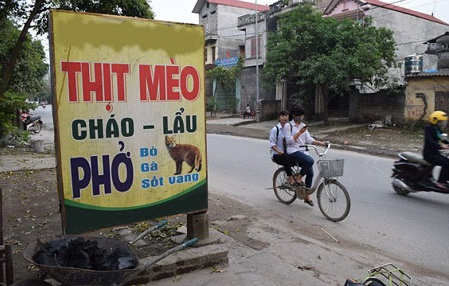

In [13]:
dataset[900]['image_path'].save('test_image.jpg')
dataset[900]['image_path']

### Let's Evaluate Deepseek-OCR Baseline Performance on Persian Transcription

In [14]:
# prompt = "<image>\nFree OCR. "
prompt = "<image>\nFree OCR. "
image_file = '/content/lam-bang-hieu-quang-cao-6.jpg'
output_path = 'content/image_test'
# infer(self, tokenizer, prompt = '', image_file = '', output_path = ' ', base_size = 1024, image_size = 768, crop_mode = True, test_compress = False, save_results = False):

# Tiny: base_size = 512, image_size = 512, crop_mode = False
# Small: base_size = 768, image_size = 768, crop_mode = False
# Base: base_size = 1024, image_size = 1024, crop_mode = False
# Large: base_size = 1280, image_size = 1280, crop_mode = False

# Gundam: base_size = 1024, image_size = 768, crop_mode = True

res = model.infer(tokenizer, prompt = prompt, image_file = image_file, output_path = output_path, base_size = 1024, image_size = 768, crop_mode = True, save_results = True, test_compress = False)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Vật  
hữ  
HỦ  
TIÊU  
BỘ  
KHO  
Xinh Mới
===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]


<h3>Baseline Model Performance: 23% Character Error Rate (CER) for this sample !</h3>

# Let's finetune Deepseek-OCR !

We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

**[NEW]** We also support finetuning ONLY the vision part of the model, or ONLY the language part. Or you can select both! You can also select to finetune the attention or the MLP layers!

In [15]:
model = FastVisionModel.get_peft_model(
    model,
    target_modules = [
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Detected MoE model with num_experts = 64 and target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']. Enabling LoRA on MoE parameters: ['mlp.experts.gate_up_proj', 'mlp.experts.down_proj']
Unsloth: PEFT set target_parameters but found no matching parameters.
This is expected for MoE models - Unsloth handles MoE expert LoRA targeting separately.


In [16]:
from datasets import Dataset

# 1. Đảm bảo dataset lấy từ danh sách mẫu gốc (chứa text và string path để tránh tràn RAM)
dataset = Dataset.from_list(samples)
dataset = dataset.select(range(min(1000, len(dataset))))

instruction = "<image>\nFree OCR. "

# 2. Định dạng hội thoại ĐÚNG chuẩn mà Data Collator yêu cầu
def convert_to_conversation(sample):
    return {
        "messages": [
            {
                "role": "<|User|>",
                "content": instruction,
                # Chèn danh sách ảnh vào trong tin nhắn của User như Data Collator mong đợi
                "images": [sample["image_path"]]
            },
            {
                "role": "<|Assistant|>",
                "content": sample["text"],
            },
        ]
    }

# 3. Tiến hành map và loại bỏ hoàn toàn các cột cũ
converted_dataset = dataset.map(
    convert_to_conversation,
    remove_columns=dataset.column_names
)

# Kiểm tra lại cấu trúc mẫu đầu tiên xem đã đúng cấu trúc chưa
print(converted_dataset[0])

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

{'messages': [{'role': '<|User|>', 'content': '<image>\nFree OCR. ', 'images': ['VinText/vietnamese/train_images/im0001.jpg']}, {'role': '<|Assistant|>', 'content': 'CHẤT LƯỢNG TỐT ĐỂ CÓ VIỆC LÀM, NĂNG SUẤT CAO ĐỂ TĂNG THU NHẬP', 'images': None}]}


In [17]:
from PIL import Image
import os

size = []

for s in sample[:20]:
  img = Image.open(s["image_path"])
  sizes.append(img.size)

print(max(s[0] for s in sizes))
print(max(s[1] for s in sizes))


NameError: name 'sample' is not defined

In [27]:
!pip install deepseek-ocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 22.1 MB/s eta 0:00:00


<a name="Data"></a>
### Data Prep
We'll be using a dataset for Persian OCR. The goal is to convert these images into a computer readable form - ie text. This can be very useful for digitizing Persian text.

You can access the dataset [here](https://huggingface.co/datasets/hezarai/parsynth-ocr-200k).

Let's convert the dataset into the "correct" format for finetuning:

We look at how the conversations are structured for the first example:

In [18]:
converted_dataset[0]

{'messages': [{'role': '<|User|>',
   'content': '<image>\nFree OCR. ',
   'images': ['VinText/vietnamese/train_images/im0001.jpg']},
  {'role': '<|Assistant|>',
   'content': 'CHẤT LƯỢNG TỐT ĐỂ CÓ VIỆC LÀM, NĂNG SUẤT CAO ĐỂ TĂNG THU NHẬP',
   'images': None}]}

In [30]:
# @title Create datacollator

import torch
import math
from dataclasses import dataclass
from typing import Dict, List, Any, Tuple
from PIL import Image, ImageOps
from torch.nn.utils.rnn import pad_sequence
import io

from deepseek_ocr2.modeling_deepseekocr2 import (
    format_messages,
    text_encode,
    BasicImageTransform,
    dynamic_preprocess,
)

@dataclass
class DeepSeekOCR2DataCollator:
    """
    Args:
        tokenizer: Tokenizer
        model: Model
        image_size: Size for image patches (default: 768)
        base_size: Size for global view (default: 1024)
        crop_mode: Whether to use dynamic cropping for large images
        train_on_responses_only: If True, only train on assistant responses (mask user prompts)
    """
    tokenizer: Any
    model: Any
    image_size: int = 768
    base_size: int = 1024
    crop_mode: bool = True
    image_token_id: int = 128815
    train_on_responses_only: bool = True

    def __init__(
        self,
        tokenizer,
        model,
        image_size: int = 768,
        base_size: int = 1024,
        crop_mode: bool = True,
        train_on_responses_only: bool = True,
    ):
        self.tokenizer = tokenizer
        self.model = model
        self.image_size = image_size
        self.base_size = base_size
        self.crop_mode = crop_mode
        self.image_token_id = 128815
        self.dtype = model.dtype  # Get dtype from model
        self.train_on_responses_only = train_on_responses_only

        self.image_transform = BasicImageTransform(
            mean = (0.5, 0.5, 0.5),
            std = (0.5, 0.5, 0.5),
            normalize = True
        )
        self.patch_size = 16
        self.downsample_ratio = 4

        # Get BOS token ID from tokenizer
        if hasattr(tokenizer, 'bos_token_id') and tokenizer.bos_token_id is not None:
            self.bos_id = tokenizer.bos_token_id
        else:
            self.bos_id = 0
            print(f"Warning: tokenizer has no bos_token_id, using default: {self.bos_id}")

    def deserialize_image(self, image_data) -> Image.Image:
        """Convert image data (bytes dict or PIL Image) to PIL Image in RGB mode"""
        if isinstance(image_data, Image.Image):
            return image_data.convert("RGB")
        elif isinstance(image_data, dict) and 'bytes' in image_data:
            image_bytes = image_data['bytes']
            image = Image.open(io.BytesIO(image_bytes))
            return image.convert("RGB")
        else:
            raise ValueError(f"Unsupported image format: {type(image_data)}")

    def calculate_image_token_count(self, image: Image.Image, crop_ratio: Tuple[int, int]) -> int:
        """Calculate the number of tokens this image will generate"""
        num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
        num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

        width_crop_num, height_crop_num = crop_ratio

        if self.crop_mode:
            img_tokens = num_queries_base * num_queries_base + 1
            if width_crop_num > 1 or height_crop_num > 1:
                img_tokens += (num_queries * width_crop_num) * (num_queries * height_crop_num)
        else:
            img_tokens = num_queries * num_queries + 1

        return img_tokens

    def process_image(self, image: Image.Image) -> Tuple[List, List, List, List, Tuple[int, int]]:
        """
        Process a single image based on crop_mode and size thresholds

        Returns:
            Tuple of (images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio)
        """
        images_list = []
        images_crop_list = []
        images_spatial_crop = []

        if self.crop_mode:
            # Determine crop ratio based on image size
            if image.size[0] <= 768 and image.size[1] <= 768:
                crop_ratio = (1, 1)
                images_crop_raw = []
            else:
                images_crop_raw, crop_ratio = dynamic_preprocess(
                    image, min_num = 2, max_num = 6,
                    image_size = self.image_size, use_thumbnail = False
                )

            # Process global view with padding
            global_view = ImageOps.pad(
                image, (self.base_size, self.base_size),
                color = tuple(int(x * 255) for x in self.image_transform.mean)
            )
            images_list.append(self.image_transform(global_view).to(self.dtype))

            width_crop_num, height_crop_num = crop_ratio
            images_spatial_crop.append([width_crop_num, height_crop_num])

            # Process local views (crops) if applicable
            if width_crop_num > 1 or height_crop_num > 1:
                for crop_img in images_crop_raw:
                    images_crop_list.append(
                        self.image_transform(crop_img).to(self.dtype)
                    )

            # Calculate image tokens
            num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
            num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

            tokenized_image = ([self.image_token_id] * num_queries_base) * num_queries_base
            tokenized_image += [self.image_token_id]

            if width_crop_num > 1 or height_crop_num > 1:
                tokenized_image += ([self.image_token_id] * (num_queries * width_crop_num)) * (
                    num_queries * height_crop_num)

        else:  # crop_mode = False
            crop_ratio = (1, 1)
            images_spatial_crop.append([1, 1])

            # For smaller base sizes, resize; for larger, pad
            if self.base_size <= 768:
                resized_image = image.resize((self.base_size, self.base_size), Image.LANCZOS)
                images_list.append(self.image_transform(resized_image).to(self.dtype))
            else:
                global_view = ImageOps.pad(
                    image, (self.base_size, self.base_size),
                    color = tuple(int(x * 255) for x in self.image_transform.mean)
                )
                images_list.append(self.image_transform(global_view).to(self.dtype))

            num_queries = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)
            tokenized_image = ([self.image_token_id] * num_queries) * num_queries
            tokenized_image += [self.image_token_id]

        return images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio

    def process_single_sample(self, messages: List[Dict]) -> Dict[str, Any]:
        """
        Process a single conversation into model inputs.
        """

        # --- 1. Setup ---
        images = []
        for message in messages:
            if "images" in message and message["images"]:
                for img_data in message["images"]:
                    if img_data is not None:
                        pil_image = self.deserialize_image(img_data)
                        images.append(pil_image)

        if not images:
            raise ValueError("No images found in sample. Please ensure all samples contain images.")

        tokenized_str = []
        images_seq_mask = []
        images_list, images_crop_list, images_spatial_crop = [], [], []

        prompt_token_count = -1 # Index to start training
        assistant_started = False
        image_idx = 0

        # Add BOS token at the very beginning
        tokenized_str.append(self.bos_id)
        images_seq_mask.append(False)

        for message in messages:
            role = message["role"]
            content = message["content"]

            # Check if this is the assistant's turn
            if role == "<|Assistant|>":
                if not assistant_started:
                    # This is the split point. All tokens added *so far*
                    # are part of the prompt.
                    prompt_token_count = len(tokenized_str)
                    assistant_started = True

                # Append the EOS token string to the *end* of assistant content
                content = f"{content.strip()} {self.tokenizer.eos_token}"

            # Split this message's content by the image token
            text_splits = content.split('<image>')

            for i, text_sep in enumerate(text_splits):
                # Tokenize the text part
                tokenized_sep = text_encode(self.tokenizer, text_sep, bos = False, eos = False)
                tokenized_str.extend(tokenized_sep)
                images_seq_mask.extend([False] * len(tokenized_sep))

                # If this text is followed by an <image> tag
                if i < len(text_splits) - 1:
                    if image_idx >= len(images):
                        raise ValueError(
                            f"Data mismatch: Found '<image>' token but no corresponding image."
                        )

                    # Process the image
                    image = images[image_idx]
                    img_list, crop_list, spatial_crop, tok_img, _ = self.process_image(image)

                    images_list.extend(img_list)
                    images_crop_list.extend(crop_list)
                    images_spatial_crop.extend(spatial_crop)

                    # Add image placeholder tokens
                    tokenized_str.extend(tok_img)
                    images_seq_mask.extend([True] * len(tok_img))

                    image_idx += 1 # Move to the next image

        # --- 3. Validation and Final Prep ---
        if image_idx != len(images):
            raise ValueError(
                f"Data mismatch: Found {len(images)} images but only {image_idx} '<image>' tokens were used."
            )

        # If we never found an assistant message, we're in a weird state
        # (e.g., user-only prompt). We mask everything.
        if not assistant_started:
            print("Warning: No assistant message found in sample. Masking all tokens.")
            prompt_token_count = len(tokenized_str)

        # Prepare image tensors
        images_ori = torch.stack(images_list, dim = 0)
        images_spatial_crop_tensor = torch.tensor(images_spatial_crop, dtype = torch.long)

        if images_crop_list:
            images_crop = torch.stack(images_crop_list, dim = 0)
        else:
            images_crop = torch.zeros((1, 3, self.base_size, self.base_size), dtype = self.dtype)

        return {
            "input_ids": torch.tensor(tokenized_str, dtype = torch.long),
            "images_seq_mask": torch.tensor(images_seq_mask, dtype = torch.bool),
            "images_ori": images_ori,
            "images_crop": images_crop,
            "images_spatial_crop": images_spatial_crop_tensor,
            "prompt_token_count": prompt_token_count, # This is now accurate
        }

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        """Collate batch of samples"""
        batch_data = []

        # Process each sample
        for feature in features:
            try:
                processed = self.process_single_sample(feature['messages'])
                batch_data.append(processed)
            except Exception as e:
                print(f"Error processing sample: {e}")
                continue

        if not batch_data:
            raise ValueError("No valid samples in batch")

        # Extract lists
        input_ids_list = [item['input_ids'] for item in batch_data]
        images_seq_mask_list = [item['images_seq_mask'] for item in batch_data]
        prompt_token_counts = [item['prompt_token_count'] for item in batch_data]

        # Pad sequences
        input_ids = pad_sequence(input_ids_list, batch_first = True, padding_value = self.tokenizer.pad_token_id)
        images_seq_mask = pad_sequence(images_seq_mask_list, batch_first = True, padding_value = False)

        # Create labels
        labels = input_ids.clone()

        # Mask padding tokens
        labels[labels == self.tokenizer.pad_token_id] = -100

        # Mask image tokens (model shouldn't predict these)
        labels[images_seq_mask] = -100

        # Mask user prompt tokens when train_on_responses_only = True (only train on assistant responses)
        if self.train_on_responses_only:
            for idx, prompt_count in enumerate(prompt_token_counts):
                if prompt_count > 0:
                    labels[idx, :prompt_count] = -100

        # Create attention mask
        attention_mask = (input_ids != self.tokenizer.pad_token_id).long()

        # Prepare images batch (list of tuples)
        images_batch = []
        for item in batch_data:
            images_batch.append((item['images_crop'], item['images_ori']))

        # Stack spatial crop info
        images_spatial_crop = torch.cat([item['images_spatial_crop'] for item in batch_data], dim = 0)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "images": images_batch,
            "images_seq_mask": images_seq_mask,
            "images_spatial_crop": images_spatial_crop,
        }

In [34]:
from transformers import Trainer, TrainingArguments
from unsloth import is_bf16_supported

# Kích hoạt chế độ huấn luyện cho mô hình (Vision Model) của Unsloth
FastVisionModel.for_training(model)

# Khởi tạo bộ gom nhóm dữ liệu (Data Collator) đã định nghĩa ở bước trước
data_collator = DeepSeekOCR2DataCollator(
    tokenizer = tokenizer,
    model = model,
    image_size = 640,          # Kích thước cho các mảnh ảnh cắt nhỏ
    base_size = 1024,          # Kích thước cho ảnh tổng thể
    crop_mode = True,          # Bật cơ chế cắt ảnh động cho ảnh lớn
    train_on_responses_only = True, # Chỉ tính loss trên câu trả lời của trợ lý
)

# Khởi tạo đối tượng Trainer để quản lý toàn bộ quá trình huấn luyện
trainer = Trainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = data_collator, # Bắt buộc phải truyền data collator chuyên dụng này vào
    train_dataset = converted_dataset, # Tập dữ liệu đã được chuyển đổi cấu trúc phù hợp
    args = TrainingArguments(
        per_device_train_batch_size = 2, # Số lượng mẫu dữ liệu xử lý trên mỗi thiết bị (GPU) trong 1 bước
        gradient_accumulation_steps = 4, # Tích lũy gradient qua 4 bước rồi mới cập nhật trọng số (Batch Size thực tế = 2 * 4 = 8)
        warmup_steps = 5,                # Số bước tăng dần tốc độ học (learning rate) từ 0 đến max để ổn định ban đầu
        max_steps = 60,                  # Tổng số bước huấn luyện tối đa (thường dùng để test nhanh)
        # num_train_epochs = 1,          # Bỏ comment dòng này nếu muốn train hết toàn bộ tập dữ liệu (Epoch) thay vì giới hạn bước
        learning_rate = 2e-4,            # Tốc độ học tối đa (Tỷ lệ điều chỉnh trọng số mô hình)
        logging_steps = 1,               # Ghi lại và hiển thị thông số (Loss, LR) sau mỗi 1 bước
        optim = "adamw_8bit",            # Sử dụng bộ tối ưu hóa AdamW phiên bản 8-bit để tiết kiệm dung lượng VRAM GPU
        weight_decay = 0.001,            # Kỹ thuật giảm hệ số trọng số để tránh hiện tượng quá khớp (Overfitting)
        lr_scheduler_type = "linear",    # Tốc độ học giảm dần theo đường thẳng sau giai đoạn warmup
        seed = 3407,                     # Đặt seed cố định để đảm bảo kết quả huấn luyện có thể tái lập lại
        fp16 = not is_bf16_supported(),  # Sử dụng kiểu dữ liệu float16 nếu GPU không hỗ trợ bfloat16 (ví dụ: GPU đời cũ như T4)
        bf16 = is_bf16_supported(),      # Sử dụng kiểu dữ liệu bfloat16 nếu GPU hỗ trợ (ví dụ: A100, H100, RTX 3090/4090...)
        output_dir = "outputs",          # Thư mục lưu trữ kết quả, checkpoint của mô hình sau khi train
        report_to = "none",              # Không gửi log lên các nền tảng như Weights & Biases (đặt "none" để tắt)
        dataloader_num_workers = 2,      # Số lượng tiến trình CPU chạy song song để tải và tiền xử lý dữ liệu ảnh/chữ

        # BẮT BUỘC phải đặt bằng False khi fine-tune các mô hình Vision-Language (Đa phương thức):
        remove_unused_columns = False,   # Không tự động xóa các cột dữ liệu không có trong chữ ký hàm định nghĩa của mô hình gốc
    ),
)

/usr/local/lib/python3.12/dist-packages/unsloth/models/_utils.py:2568: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  _original_trainer_init(self, *args, **kwargs)


In [39]:
# @title Tạo datacollator

import torch
import math
from dataclasses import dataclass
from typing import Dict, List, Any, Tuple
from PIL import Image, ImageOps
from torch.nn.utils.rnn import pad_sequence
import io

# Khởi tạo các hàm bổ trợ từ thư viện deepseek_ocr
from deepseek_ocr2.modeling_deepseekocr2 import (
    format_messages,
    text_encode,
    BasicImageTransform,
    dynamic_preprocess,
)

@dataclass
class DeepSeekOCRDataCollator:
    """
    Các tham số đầu vào:
        tokenizer: Bộ mã hóa văn bản (Tokenizer)
        model: Mô hình DeepSeek OCR
        image_size: Kích thước cho các ô ảnh nhỏ - image patches (mặc định: 640)
        base_size: Kích thước cho ảnh tổng thể - global view (mặc định: 1024)
        crop_mode: Có sử dụng cơ chế cắt ảnh động (dynamic cropping) cho ảnh lớn không
        train_on_responses_only: Nếu True, chỉ tính loss trên câu trả lời của trợ lý (ẩn prompt của user)
    """
    tokenizer: Any
    model: Any
    image_size: int = 640
    base_size: int = 1024
    crop_mode: bool = True
    image_token_id: int = 128815
    train_on_responses_only: bool = True

    def __init__(
        self,
        tokenizer,
        model,
        image_size: int = 640,
        base_size: int = 1024,
        crop_mode: bool = True,
        train_on_responses_only: bool = True,
    ):
        self.tokenizer = tokenizer
        self.model = model
        self.image_size = image_size
        self.base_size = base_size
        self.crop_mode = crop_mode
        self.image_token_id = 128815
        self.dtype = model.dtype  # Lấy kiểu dữ liệu (float16/bfloat16...) trực tiếp từ mô hình
        self.train_on_responses_only = train_on_responses_only

        # Cấu hình chuẩn hóa ảnh (Đưa giá trị pixel về khoảng [-1, 1])
        self.image_transform = BasicImageTransform(
            mean = (0.5, 0.5, 0.5),
            std = (0.5, 0.5, 0.5),
            normalize = True
        )
        self.patch_size = 16          # Kích thước mỗi patch ảnh nhỏ
        self.downsample_ratio = 4     # Tỷ lệ giảm mẫu (downsample) của Vision Encoder

        # Lấy ID của token bắt đầu chuỗi (BOS), nếu không có thì mặc định là 0
        if hasattr(tokenizer, 'bos_token_id') and tokenizer.bos_token_id is not None:
            self.bos_id = tokenizer.bos_token_id
        else:
            self.bos_id = 0
            print(f"Cảnh báo: tokenizer không có bos_token_id, sử dụng mặc định: {self.bos_id}")

    def deserialize_image(self, image_data) -> Image.Image:
        """Chuyển đổi dữ liệu ảnh (dạng bytes hoặc PIL Image) về dạng PIL Image hệ màu RGB"""
        if isinstance(image_data, Image.Image):
            return image_data.convert("RGB")
        elif isinstance(image_data, dict) and 'bytes' in image_data:
            image_bytes = image_data['bytes']
            image = Image.open(io.BytesIO(image_bytes))
            return image.convert("RGB")
        else:
            raise ValueError(f"Định dạng ảnh không được hỗ trợ: {type(image_data)}")

    def calculate_image_token_count(self, image: Image.Image, crop_ratio: Tuple[int, int]) -> int:
        """Tính toán số lượng token hình ảnh mà bức ảnh này sẽ tạo ra"""
        # Số lượng query token cho ảnh cục bộ (local crop) và ảnh tổng thể (base view)
        num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
        num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

        width_crop_num, height_crop_num = crop_ratio

        if self.crop_mode:
            # Ảnh tổng thể đóng góp (num_queries_base^2 + 1) token
            img_tokens = num_queries_base * num_queries_base + 1
            # Nếu ảnh bị cắt thành nhiều mảnh nhỏ, cộng thêm số token của các mảnh đó
            if width_crop_num > 1 or height_crop_num > 1:
                img_tokens += (num_queries * width_crop_num + 1) * (num_queries * height_crop_num)
        else:
            # Nếu không crop, số token tính theo kích thước base ban đầu
            img_tokens = num_queries * num_queries + 1

        return img_tokens

    def process_image(self, image: Image.Image) -> Tuple[List, List, List, List, Tuple[int, int]]:
        """
        Xử lý một bức ảnh dựa trên chế độ crop_mode và ngưỡng kích thước ảnh.
        Trả về: Bản sao ảnh gốc, danh sách ảnh cắt nhỏ, thông tin lưới cắt, chuỗi token ảnh, và tỷ lệ crop.
        """
        images_list = []
        images_crop_list = []
        images_spatial_crop = []

        if self.crop_mode:
            # Nếu ảnh nhỏ hơn hoặc bằng 640x640 thì giữ nguyên, không cắt mảnh
            if image.size[0] <= 640 and image.size[1] <= 640:
                crop_ratio = (1, 1)
                images_crop_raw = []
            else:
                # Ngược lại, áp dụng thuật toán cắt động (cắt thành từ 2 đến 9 mảnh nhỏ)
                images_crop_raw, crop_ratio = dynamic_preprocess(
                    image, min_num = 2, max_num = 9,
                    image_size = self.image_size, use_thumbnail = False
                )

            # Xử lý ảnh tổng thể (Global View) bằng cách thêm viền (padding) về kích thước base_size x base_size
            global_view = ImageOps.pad(
                image, (self.base_size, self.base_size),
                color = tuple(int(x * 255) for x in self.image_transform.mean)
            )
            images_list.append(self.image_transform(global_view).to(self.dtype))

            width_crop_num, height_crop_num = crop_ratio

            images_spatial_crop.append([width_crop_num, height_crop_num])

            # Chuẩn hóa và chuyển kiểu dữ liệu cho từng mảnh ảnh nhỏ (Local Views)
            if width_crop_num > 1 or height_crop_num > 1:
                for crop_img in images_crop_raw:
                    images_crop_list.append(
                        self.image_transform(crop_img).to(self.dtype)
                    )

            # --- Tính toán chuỗi token đại diện cho ảnh để chèn vào văn bản ---
            num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
            num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

            # Khởi tạo danh sách các token ảnh cho ảnh tổng thể
            tokenized_image = ([self.image_token_id] * num_queries_base + [self.image_token_id]) * num_queries_base
            tokenized_image += [self.image_token_id]

            # Nếu có cắt mảnh, cộng thêm chuỗi token đại diện cho các mảnh nhỏ
            if width_crop_num > 1 or height_crop_num > 1:
                tokenized_image += ([self.image_token_id] * (num_queries * width_crop_num) + [self.image_token_id]) * (
                    num_queries * height_crop_num)

        else:  # Trường hợp crop_mode = False (Không dùng cơ chế cắt ảnh động)
            crop_ratio = (1, 1)
            images_spatial_crop.append([1, 1])

            # Nếu base_size nhỏ thì resize ảnh, lớn hơn thì thêm viền (pad) để tránh mất chi tiết
            if self.base_size <= 640:
                resized_image = image.resize((self.base_size, self.base_size), Image.LANCZOS)
                images_list.append(self.image_transform(resized_image).to(self.dtype))
            else:
                global_view = ImageOps.pad(
                    image, (self.base_size, self.base_size),
                    color = tuple(int(x * 255) for x in self.image_transform.mean)
                )
                images_list.append(self.image_transform(global_view).to(self.dtype))

            num_queries = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)
            tokenized_image = ([self.image_token_id] * num_queries + [self.image_token_id]) * num_queries
            tokenized_image += [self.image_token_id]

        return images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio

    def process_single_sample(self, messages: List[Dict]) -> Dict[str, Any]:
        """Xử lý một cuộc hội thoại đơn lẻ thành các tensor đầu vào cho mô hình."""

        # --- Bước 1: Trích xuất và giải mã toàn bộ ảnh trong đoạn chat ---
        images = []
        for message in messages:
            if "images" in message and message["images"]:
                for img_data in message["images"]:
                  if img_data is not None:
                        pil_image = self.deserialize_image(img_data)
                        images.append(pil_image)

        if not images:
            raise ValueError("Không tìm thấy ảnh trong dữ liệu mẫu. Đảm bảo mọi mẫu đều chứa ảnh.")

        tokenized_str = []       # Chứa toàn bộ chuỗi ID token (cả chữ lẫn ảnh)
        images_seq_mask = []     # Mask đánh dấu vị trí nào là token của ảnh (True) hay chữ (False)
        images_list, images_crop_list, images_spatial_crop = [], [], []

        prompt_token_count = -1  # Biến đếm số token của prompt (để biết vị trí bắt đầu câu trả lời)
        assistant_started = False
        image_idx = 0

        # Thêm token bắt đầu chuỗi (BOS) vào đầu đoạn hội thoại
        tokenized_str.append(self.bos_id)
        images_seq_mask.append(False)

        # --- Bước 2: Duyệt qua từng tin nhắn (User / Assistant) ---
        for message in messages:
            role = message["role"]
            content = message["content"]

            # Kiểm tra xem có phải lượt thoại của Assistant (Trợ lý) không
            if role == "<|Assistant|>" :
                if not assistant_started:
                    # Điểm phân tách: Toàn bộ token trước lượt Assistant đầu tiên được tính là Prompt (User)
                    prompt_token_count = len(tokenized_str)
                    assistant_started = True

                # Tự động thêm token kết thúc chuỗi (EOS) vào cuối câu trả lời của Assistant
                content = f"{content.strip()} {self.tokenizer.eos_token}"

            # Tách nội dung văn bản dựa trên thẻ vị trí ảnh `<image>`
            text_splits = content.split('<image>')

            for i, text_sep in enumerate(text_splits):
                # Mã hóa phần văn bản thuần túy (không kèm BOS/EOS riêng lẻ)
                tokenized_sep = text_encode(self.tokenizer, text_sep, bos = False, eos = False)
                tokenized_str.extend(tokenized_sep)
                images_seq_mask.extend([False] * len(tokenized_sep))

                # Nếu sau phần văn bản này có một thẻ `<image>`
                if i < len(text_splits) - 1:
                    if image_idx >= len(images):
                        raise ValueError("Lỗi bất đồng bộ: Thấy thẻ '<image>' nhưng không tìm thấy ảnh tương ứng.")

                    # Lấy ảnh ra và tiến hành xử lý (crop, pad, chuyển tensor)
                    image = images[image_idx]
                    img_list, crop_list, spatial_crop, tok_img, _ = self.process_image(image)

                    images_list.extend(img_list)
                    images_crop_list.extend(crop_list)
                    images_spatial_crop.extend(spatial_crop)
                    # Thay thế thẻ `<image>` bằng một chuỗi các token ảnh (`image_token_id`) giữ chỗ
                    tokenized_str.extend(tok_img)
                    images_seq_mask.extend([True] * len(tok_img))

                    image_idx += 1  # Chuyển sang xử lý bức ảnh tiếp theo

        # --- Bước 3: Kiểm tra hợp lệ và đóng gói dữ liệu thành Tensor ---
        if image_idx != len(images):
            raise ValueError(f"Lỗi bất đồng bộ: Có {len(images)} ảnh nhưng chỉ dùng {image_idx} thẻ '<image>'.")

        # Nếu cuộc hội thoại lỗi không có câu trả lời của trợ lý, ẩn (mask) toàn bộ chuỗi
        if not assistant_started:
            print("Cảnh báo: Không tìm thấy tin nhắn của Assistant. Ẩn toàn bộ token.")
            prompt_token_count = len(tokenized_str)

        # Chuyển đổi danh sách ảnh thành các Tensor PyTorch
        images_ori = torch.stack(images_list, dim = 0)
        images_spatial_crop_tensor = torch.tensor(images_spatial_crop, dtype = torch.long)

        if images_crop_list:
            images_crop = torch.stack(images_crop_list, dim = 0)
        else:
            # Tạo tensor rỗng nếu không có mảnh cắt ảnh nào
            images_crop = torch.zeros((1, 3, self.base_size, self.base_size), dtype = self.dtype)

        return {
            "input_ids": torch.tensor(tokenized_str, dtype = torch.long),
            "images_seq_mask": torch.tensor(images_seq_mask, dtype = torch.bool),
            "images_ori": images_ori,
            "images_crop": images_crop,
            "images_spatial_crop": images_spatial_crop_tensor,
            "prompt_token_count": prompt_token_count,
        }

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        """Gộp một nhóm (batch) các mẫu dữ liệu đơn lẻ lại thành một batch đồng nhất"""
        batch_data = []

        # Xử lý từng mẫu trong danh sách đầu vào
        for feature in features:
            try:
                processed = self.process_single_sample(feature['messages'])
                batch_data.append(processed)
            except Exception as e:
                print(f"Lỗi khi xử lý mẫu dữ liệu: {e}")
                continue

        if not batch_data:
            raise ValueError("Không có mẫu dữ liệu nào hợp lệ trong batch")

        # Gom nhóm các trường thông tin tương ứng từ các mẫu
        input_ids_list = [item['input_ids'] for item in batch_data]
        images_seq_mask_list = [item['images_seq_mask'] for item in batch_data]
        prompt_token_counts = [item['prompt_token_count'] for item in batch_data]

        # Áp dụng đệm (padding) để các chuỗi trong batch có chiều dài bằng nhau
        input_ids = pad_sequence(input_ids_list, batch_first = True, padding_value = self.tokenizer.pad_token_id)
        images_seq_mask = pad_sequence(images_seq_mask_list, batch_first = True, padding_value = False)

        # Tạo nhãn (labels) để huấn luyện (bản sao của input_ids)
        labels = input_ids.clone()

        # Đặt nhãn bằng -100 đối với các token đệm (Mô hình PyTorch sẽ bỏ qua không tính loss tại vị trí -100)
        labels[labels == self.tokenizer.pad_token_id] = -100

        # Đặt nhãn bằng -100 đối với các token của ảnh (Mô hình chỉ học sinh ra chữ, không sinh ra ảnh)
        labels[images_seq_mask] = -100

        # Nếu bật chế độ chỉ train trên câu trả lời, đặt nhãn bằng -100 cho toàn bộ phần Prompt của User
        if self.train_on_responses_only:
            for idx, prompt_count in enumerate(prompt_token_counts):
                if prompt_count > 0:
                    labels[idx, :prompt_count] = -100

        # Tạo attention mask (Vị trí token thực là 1, vị trí token đệm pad là 0)
        attention_mask = (input_ids != self.tokenizer.pad_token_id).long()

        # Chuẩn bị batch hình ảnh (dạng danh sách chứa các bộ tuple ảnh crop và ảnh gốc)
        images_batch = []
        for item in batch_data:
            images_batch.append((item['images_crop'], item['images_ori']))

        # Gộp thông tin cấu trúc lưới cắt (spatial crop)
        images_spatial_crop = torch.cat([item['images_spatial_crop'] for item in batch_data], dim = 0)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "images": images_batch,
            "images_seq_mask": images_seq_mask,
            "images_spatial_crop": images_spatial_crop,
        }
        # Khối lệnh này tạm thời bị tắt (if False). Khi đổi thành 'if True:', nó sẽ tải lại mô hình đã huấn luyện để chạy độc lập.
if False:
    from unsloth import FastVisionModel

    # Tải lại mô hình gốc kèm theo trọng số LoRA đã được fine-tune từ thư mục cục bộ
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "deepseek_ocr_lora",      # Tên thư mục chứa mô hình/weights bạn đã lưu trước đó
        load_in_4bit = False,                  # Đặt thành True nếu muốn dùng 4-bit để tiết kiệm VRAM; False để giữ 16-bit LoRA chuẩn
        auto_model = AutoModel,                # Lớp mô hình tự động từ thư viện transformers
        trust_remote_code = True,              # Cho phép chạy code tùy chỉnh từ kho lưu trữ của mô hình (bắt buộc cho DeepSeek)
        unsloth_force_compile = True,          # Ép buộc biên dịch mô hình qua bộ công cụ tăng tốc của Unsloth để tăng tốc độ suy luận
        use_gradient_checkpointing = "unsloth",# Cơ chế tối ưu hóa bộ nhớ cho các chuỗi văn bản dài (long context)
    )
    # Chuyển mô hình sang chế độ tối ưu riêng cho việc chạy suy luận/dự đoán (Inference) thay vì huấn luyện
    FastVisionModel.for_inference(model)

# --- THIẾT LẬP ĐẦU VÀO ĐỂ CHẠY OCR ---
prompt = "<image>\nFree OCR. "           # Thẻ chỉ định vị trí ảnh và yêu cầu tác vụ OCR tự do
image_file = '/content/test_image.jpg'            # Đường dẫn tới file ảnh đầu vào của bạn
output_path = 'your/output/dir'          # Đường dẫn thư mục để lưu kết quả văn bản đầu ra

# --- BẢNG TRA CỨU CẤU HÌNH KÍCH THƯỚC ẢNH (GHI CHÚ) ---
# Tiny:  base_size = 512,  image_size = 512,  crop_mode = False
# Small: base_size = 640,  image_size = 640,  crop_mode = False
# Base:  base_size = 1024, image_size = 1024, crop_mode = False
# Large: base_size = 1280, image_size = 1280, crop_mode = False

# Gundam (Cấu hình tối ưu cao): base_size = 1024, image_size = 640, crop_mode = True
# -----------------------------------------------------

# Thực hiện quét OCR và nhận diện văn bản trên bức ảnh
res = model.infer(
    tokenizer,
    prompt = prompt,
    image_file = image_file,
    output_path = output_path,
    image_size = 640,
    base_size = 1024,
    crop_mode = True,         # Sử dụng thuật toán cắt ảnh động để giữ nguyên độ nét cho chữ nhỏ
    save_results = True,      # Tự động xuất kết quả ra file văn bản trong thư mục output_path
    test_compress = False     # Giữ nguyên chất lượng ảnh thô để nhận diện chính xác nhất
)

THỊT MEO  
CHÂU - LẠU  
PHỞ gà  
sốt uống
===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]


END



<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support `DPOTrainer` and `GRPOTrainer` for reinforcement learning!!

We use our new `DeepSeekOCR2DataCollator` which will help in our vision finetuning setup.

In [ ]:
from transformers import Trainer, TrainingArguments
from unsloth import is_bf16_supported
FastVisionModel.for_training(model) # Enable for training!
data_collator = DeepSeekOCR2DataCollator(
    tokenizer = tokenizer,
    model = model,
    image_size = 768,
    base_size = 1024,
    crop_mode = True,
    train_on_responses_only = True,
)
trainer = Trainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = data_collator, # Must use!
    train_dataset = converted_dataset,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        # num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        fp16 = not is_bf16_supported(),  # Use fp16 if bf16 is not supported
        bf16 = is_bf16_supported(),  # Use bf16 if supported
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases
        dataloader_num_workers = 2,
        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
    ),
)

/tmp/ipython-input-1258209068.py:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer._unsloth___init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
6.838 GB of memory reserved.


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

744.5682 seconds used for training.
12.41 minutes used for training.
Peak reserved memory = 8.367 GB.
Peak reserved memory for training = 1.529 GB.
Peak reserved memory % of max memory = 56.76 %.
Peak reserved memory for training % of max memory = 10.372 %.


<a name="Inference"></a>
### Inference
Let's run the model!

<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [ ]:
model.save_pretrained("deepseek_ocr_lora")  # Local saving
tokenizer.save_pretrained("deepseek_ocr_lora")
# model.push_to_hub("your_name/deepseek_ocr_lora", token = "YOUR_HF_TOKEN") # Online saving
# tokenizer.push_to_hub("your_name/deepseek_ocr_lora", token = "YOUR_HF_TOKEN") # Online saving

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR2. This is not supported for all configurations of models and can yield errors.


('lora_model/tokenizer_config.json',
 'lora_model/special_tokens_map.json',
 'lora_model/tokenizer.json')

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [ ]:
if False:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "deepseek_ocr_lora", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = False, # Use 4bit to reduce memory use. False for 16bit LoRA.
        auto_model = AutoModel,
        trust_remote_code = True,
        unsloth_force_compile = True,
        use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
    )
    FastVisionModel.for_inference(model) # Enable for inference!

prompt = "<image>\nFree OCR. "
image_file = 'your_image.jpg'
output_path = 'your/output/dir'

# Tiny: base_size = 512, image_size = 512, crop_mode = False
# Small: base_size = 768, image_size = 768, crop_mode = False
# Base: base_size = 1024, image_size = 1024, crop_mode = False
# Large: base_size = 1280, image_size = 1280, crop_mode = False

# Gundam: base_size = 1024, image_size = 768, crop_mode = True

res = model.infer(tokenizer, prompt = prompt, image_file = image_file,
    output_path = output_path,
    image_size = 768,
    base_size = 1024,
    crop_mode = True,
    save_results = True,
    test_compress = False)

انضباطم شدم حقیقتن باورم نمیشه
===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]


### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens. See [our docs](https://unsloth.ai/docs/basics/inference-and-deployment) for more deployment options.

In [ ]:
# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit
if False: model.save_pretrained_merged("unsloth_finetune", tokenizer,)

# To export and save to your Hugging Face account
if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", tokenizer, token = "YOUR_HF_TOKEN")

And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other resources:
1. Train your own reasoning model - Llama GRPO notebook [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.1_(8B)-GRPO.ipynb)
2. Saving finetunes to Ollama. [Free notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)
3. Llama 3.2 Vision finetuning - Radiography use case. [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.2_(11B)-Vision.ipynb)
4. See notebooks for DPO, ORPO, Continued pretraining, conversational finetuning and more on our [documentation](https://unsloth.ai/docs/get-started/unsloth-notebooks)!

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️

  This notebook and all Unsloth notebooks are licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme)
</div>